In [1]:
1+1

2

In [3]:
import os

print("현재 파이썬이 있는 위치:", os.getcwd())
print("이 폴더에 있는 파일 목록:", os.listdir())

현재 파이썬이 있는 위치: c:\workdir\space-cap\python-real-estate-analysis\notebooks
이 폴더에 있는 파일 목록: ['01_monthly_apt_trend.ipynb']


기본 데이터 로드 및 탐색 코드

In [4]:
import pandas as pd

# 1. 데이터 불러오기 (경로는 실제 파일 위치에 맞게 수정하세요)
file_path = '../data/월간 아파트 매매가격지수_20260408.xlsx'

# 엑셀 파일 읽기
# (csv로 변환된 파일이 있다면 pd.read_csv('파일명.csv')를 사용하셔도 됩니다)
df = pd.read_excel(file_path, engine='openpyxl')

# 2. 데이터 크기 확인 (행, 열 개수)
print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열\n")

# 3. 데이터 상위 5개 행 확인
display(df.head())

데이터 크기: 283행, 122열



,지역명,2016-03-01 09:00:52,2016-04-01 09:00:52,2016-05-01 09:00:52,2016-06-01 09:00:52,2016-07-01 09:00:52,2016-08-01 09:00:52,2016-09-01 09:00:52,2016-10-01 09:00:52,2016-11-01 09:00:52,...,2025-06-01 09:00:52,2025-07-01 09:00:52,2025-08-01 09:00:52,2025-09-01 09:00:52,2025-10-01 09:00:52,2025-11-01 09:00:52,2025-12-01 09:00:52,2026-01-01 09:00:52,2026-02-01 09:00:52,2026-03-01 09:00:52
0,전국,71.758939,71.780898,71.831308,71.895842,71.996097,72.098278,72.20752,72.41693,72.646086,...,89.457531,89.644476,89.671964,89.765775,90.019231,90.384846,90.669762,90.896435,91.264115,91.662871
1,서울,59.321167,59.391413,59.557238,59.794862,60.119852,60.456648,60.719965,61.155619,61.559396,...,96.898136,98.141807,98.7261,99.532833,100.983905,102.71722,103.80823,104.710833,106.109913,107.626057
2,강북14개구,59.638267,59.716303,59.838758,60.00187,60.250068,60.516119,60.722059,61.075993,61.483568,...,91.409396,92.357822,92.704463,93.309082,94.480477,95.927784,96.644737,97.360009,98.632676,100.317304
3,종로구,72.712626,72.790043,72.962052,73.042199,73.170641,73.357789,73.457794,73.69682,73.955765,...,102.532116,102.988925,103.178224,103.53731,103.806813,104.693372,105.540645,105.817513,106.887685,108.334017
4,중구,67.441888,67.441918,67.564474,67.832946,68.009125,68.271665,68.454258,68.747363,69.020794,...,99.237375,100.485793,100.794674,102.351724,104.150153,106.966954,109.1411,109.884284,111.114037,112.603016


1단계: 원하는 지역만 쏙 뽑아보기 (Filtering)

In [5]:
# '지역명' 컬럼에 어떤 지역들이 있는지 처음 20개만 확인
print("지역 목록 미리보기:")
print(df['지역명'].unique()[:20])
print("-" * 50)

# '서울' 지역 데이터만 필터링하기 (만약 '서울특별시'로 되어있다면 이름을 맞춰주세요)
# 엑셀 원본에 따라 '전국', '수도권', '강남구' 등으로 바꿔서 테스트해 보세요!
target_region = '서울' 
df_seoul = df[df['지역명'] == target_region]

display(df_seoul)

지역 목록 미리보기:
<StringArray>
[    '전국',     '서울', '강북14개구',    '종로구',     '중구',    '용산구',    '성동구',
    '광진구',   '동대문구',    '중랑구',    '성북구',    '강북구',    '도봉구',    '노원구',
    '은평구',   '서대문구',    '마포구', '강남11개구',    '양천구',    '강서구']
Length: 20, dtype: str
--------------------------------------------------


,지역명,2016-03-01 09:00:52,2016-04-01 09:00:52,2016-05-01 09:00:52,2016-06-01 09:00:52,2016-07-01 09:00:52,2016-08-01 09:00:52,2016-09-01 09:00:52,2016-10-01 09:00:52,2016-11-01 09:00:52,...,2025-06-01 09:00:52,2025-07-01 09:00:52,2025-08-01 09:00:52,2025-09-01 09:00:52,2025-10-01 09:00:52,2025-11-01 09:00:52,2025-12-01 09:00:52,2026-01-01 09:00:52,2026-02-01 09:00:52,2026-03-01 09:00:52
1,서울,59.321167,59.391413,59.557238,59.794862,60.119852,60.456648,60.719965,61.155619,61.559396,...,96.898136,98.141807,98.7261,99.532833,100.983905,102.71722,103.80823,104.710833,106.109913,107.626057


2단계: 데이터 구조 바꾸기 (가장 중요 ⭐️)

In [6]:
# melt를 이용해 가로로 긴 데이터를 세로로 변환
df_long = pd.melt(
    df_seoul, 
    id_vars=['지역명'],        # 유지할 기준 컬럼
    var_name='날짜',          # 컬럼 이름들이 모일 새로운 컬럼명
    value_name='매매가격지수'  # 실제 값들이 모일 새로운 컬럼명
)

# 날짜 컬럼을 진짜 '날짜(datetime)' 타입으로 변환
df_long['날짜'] = pd.to_datetime(df_long['날짜'], errors='coerce')

# 결과 확인
print("✅ 가로로 길었던 데이터가 세로로 변환되었습니다!")
display(df_long.head())

✅ 가로로 길었던 데이터가 세로로 변환되었습니다!


,지역명,날짜,매매가격지수
0,서울,2016-03-01 09:00:52,59.321167
1,서울,2016-04-01 09:00:52,59.391413
2,서울,2016-05-01 09:00:52,59.557238
3,서울,2016-06-01 09:00:52,59.794862
4,서울,2016-07-01 09:00:52,60.119852


선 그래프(Line Chart)

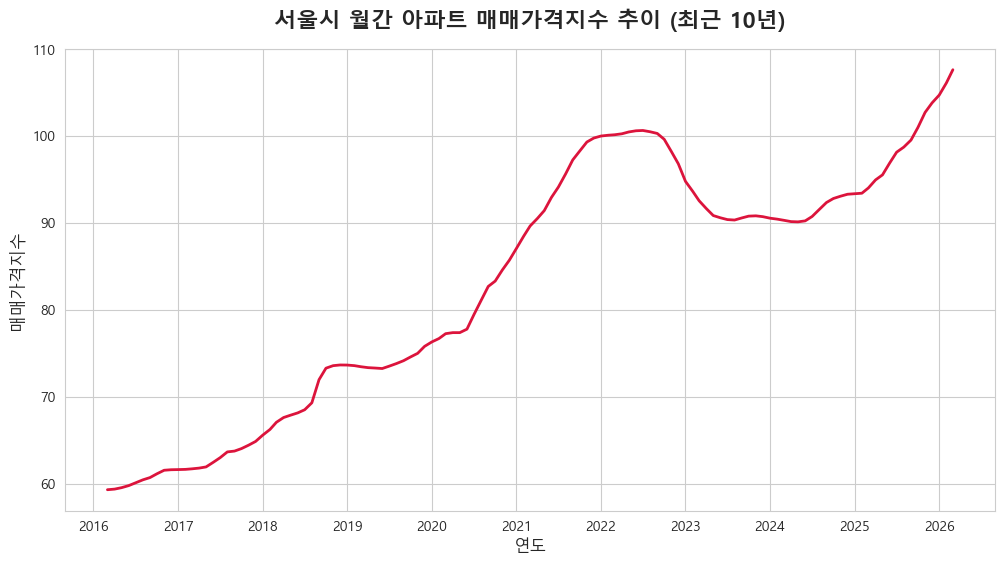

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# (참고: 만약 Mac을 사용 중이시라면 위 'Malgun Gothic' 대신 'AppleGothic'을 입력하세요)

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # 배경에 옅은 격자무늬 추가
plt.rcParams['font.family'] = 'Malgun Gothic' # seaborn 테마 적용 후 폰트 재설정

# 3. 선 그래프 그리기
# x축은 날짜, y축은 매매가격지수
sns.lineplot(data=df_long, x='날짜', y='매매가격지수', color='crimson', linewidth=2)

# 4. 제목 및 축 이름 설정
plt.title('서울시 월간 아파트 매매가격지수 추이 (최근 10년)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('매매가격지수', fontsize=12)

# 5. 그래프 출력
plt.show()

'전국', '서울', '경기' 세 곳의 데이터를 한 번에 뽑아서, 그래프 안에 3개의 선이 그려지도록 만들기

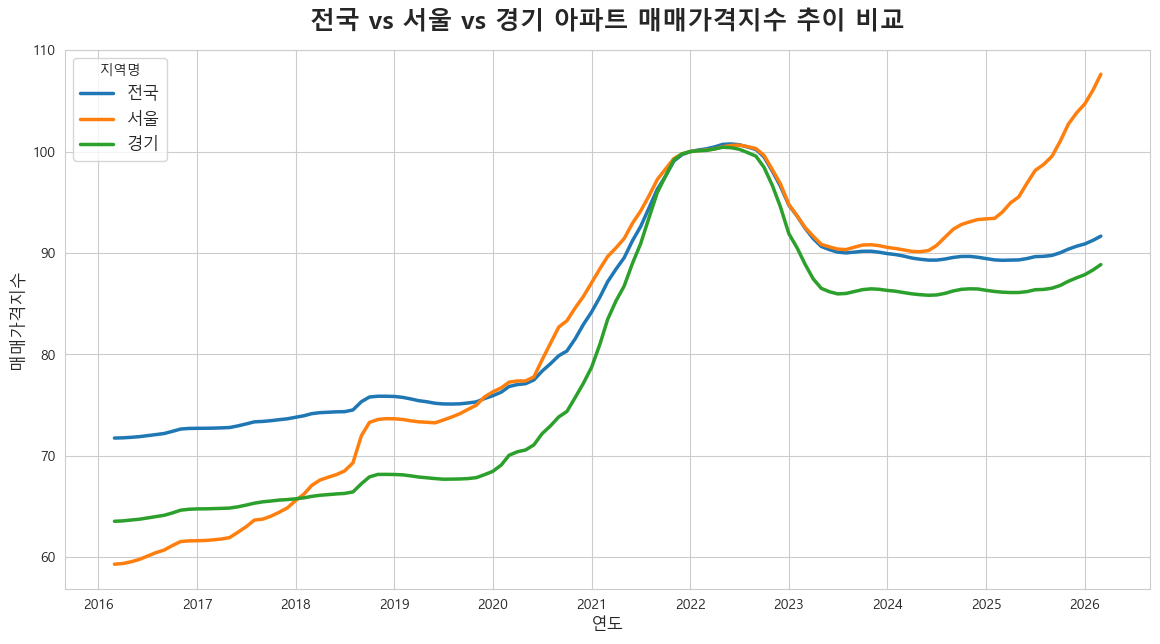

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 비교하고 싶은 지역들을 리스트로 묶기
target_regions = ['전국', '서울', '경기']

# 2. isin() 함수를 써서 해당 지역들만 한 번에 필터링
df_compare = df[df['지역명'].isin(target_regions)]

# 3. 가로 데이터를 세로로 변환 (Melt)
df_compare_long = pd.melt(
    df_compare, 
    id_vars=['지역명'], 
    var_name='날짜', 
    value_name='매매가격지수'
)

# 4. 날짜 데이터 타입 변환
df_compare_long['날짜'] = pd.to_datetime(df_compare_long['날짜'], errors='coerce')

# --- 여기서부터 시각화 ---
# 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'

# 5. 선 그래프 그리기 (핵심: hue='지역명'을 넣으면 지역별로 선이 나뉘어 그려집니다!)
sns.lineplot(
    data=df_compare_long, 
    x='날짜', 
    y='매매가격지수', 
    hue='지역명',      # 지역별로 색상 다르게 하기
    linewidth=2.5
)

# 6. 제목, 축, 범례(Legend) 설정
plt.title('전국 vs 서울 vs 경기 아파트 매매가격지수 추이 비교', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('매매가격지수', fontsize=12)
plt.legend(title='지역명', fontsize=12, loc='upper left') # 범례 위치를 왼쪽 위로

plt.show()

서울 부동산 시장의 핵심인 '지역 간 격차(양극화)' 흐름

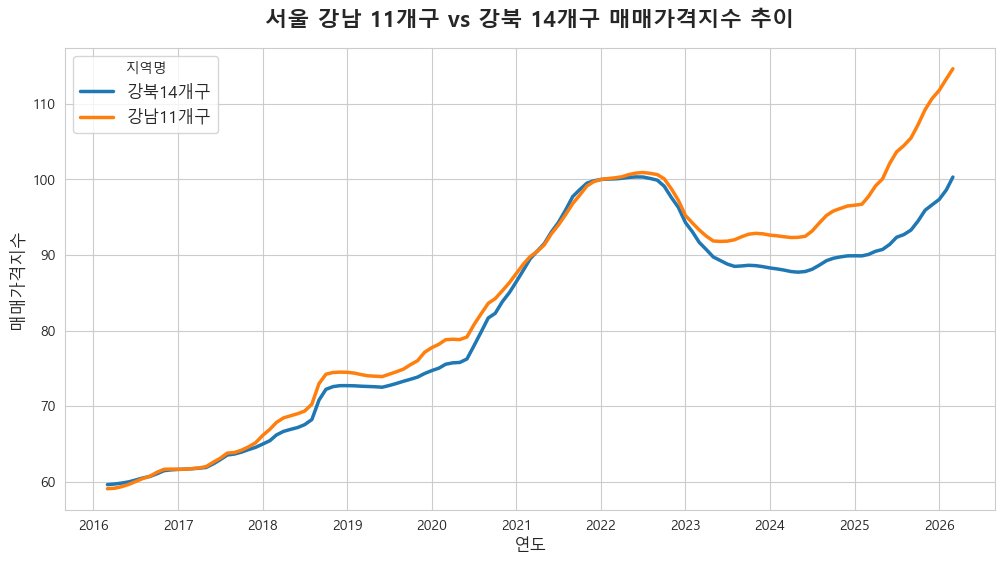

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 강북14개구, 강남11개구만 필터링
target_regions = ['강북14개구', '강남11개구']

# 만약 데이터 원본에 이름이 조금 다르다면 (예: '강북권', '강남권') 아래 리스트를 수정해 주세요.
df_gang = df[df['지역명'].isin(target_regions)]

# 2. 데이터 구조 변환 (Melt)
df_gang_long = pd.melt(
    df_gang, 
    id_vars=['지역명'], 
    var_name='날짜', 
    value_name='매매가격지수'
)

# 3. 날짜 형식 변환
df_gang_long['날짜'] = pd.to_datetime(df_gang_long['날짜'], errors='coerce')

# --- 시각화 설정 ---
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # 스타일 적용 후 폰트 재설정 필수

# 4. 선 그래프 그리기
sns.lineplot(
    data=df_gang_long, 
    x='날짜', 
    y='매매가격지수', 
    hue='지역명', 
    palette=['#1f77b4', '#ff7f0e'], # 파란색, 주황색으로 명확히 대비되도록 설정
    linewidth=2.5
)

# 5. 제목 및 축 설정
plt.title('서울 강남 11개구 vs 강북 14개구 매매가격지수 추이', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('매매가격지수', fontsize=12)
plt.legend(title='지역명', fontsize=12, loc='upper left')

plt.show()

In [10]:
# 1. 지역별 역대 최고 지수(고점) 찾기
max_price = df_gang_long.groupby('지역명')['매매가격지수'].max()

# 2. 가장 최근 데이터(마지막 달) 지수 찾기
latest_date = df_gang_long['날짜'].max()
latest_price = df_gang_long[df_gang_long['날짜'] == latest_date].set_index('지역명')['매매가격지수']

# 3. 고점 대비 하락률 계산: (최근값 - 고점) / 고점 * 100
drop_rate = ((latest_price - max_price) / max_price) * 100

# 4. 결과 깔끔하게 출력하기
print(f"📊 분석 기준월(최근 데이터): {latest_date.strftime('%Y년 %m월')}\n")
print("-" * 30)

for region in target_regions:
    print(f"[{region}]")
    print(f"- 역대 최고 지수: {max_price[region]:.1f}")
    print(f"- 최근 현재 지수: {latest_price[region]:.1f}")
    print(f"- 고점 대비 하락률: {drop_rate[region]:.2f}%\n")

📊 분석 기준월(최근 데이터): 2026년 03월

------------------------------
[강북14개구]
- 역대 최고 지수: 100.3
- 최근 현재 지수: 100.3
- 고점 대비 하락률: -0.02%

[강남11개구]
- 역대 최고 지수: 114.6
- 최근 현재 지수: 114.6
- 고점 대비 하락률: 0.00%



In [11]:
# 1. 딱 1년 전 날짜 계산하기
one_year_ago = latest_date - pd.DateOffset(years=1)

# 2. 1년 전(2025년 3월)의 매매가격지수 가져오기
price_1y_ago = df_gang_long[df_gang_long['날짜'] == one_year_ago].set_index('지역명')['매매가격지수']

# 3. 최근 1년간 상승률(YoY) 계산: (현재값 - 1년전값) / 1년전값 * 100
yoy_growth = ((latest_price - price_1y_ago) / price_1y_ago) * 100

# 4. 결과 출력
print(f"📈 최근 1년간 아파트 가격 상승률 ({one_year_ago.strftime('%Y년 %m월')} ~ {latest_date.strftime('%Y년 %m월')})\n")
print("-" * 40)

for region in target_regions:
    print(f"[{region}]")
    print(f"- 1년 전 지수: {price_1y_ago[region]:.1f}")
    print(f"- 최근 지수: {latest_price[region]:.1f}")
    
    # 상승/하락에 따라 기호 다르게 표시
    sign = "+" if yoy_growth[region] > 0 else ""
    print(f"👉 1년 변동률: {sign}{yoy_growth[region]:.2f}%\n")

📈 최근 1년간 아파트 가격 상승률 (2025년 03월 ~ 2026년 03월)

----------------------------------------
[강북14개구]
- 1년 전 지수: 90.1
- 최근 지수: 100.3
👉 1년 변동률: +11.37%

[강남11개구]
- 1년 전 지수: 97.7
- 최근 지수: 114.6
👉 1년 변동률: +17.30%



In [18]:
import pandas as pd

# 1. 서울의 25개 자치구 이름 리스트
seoul_gu_list = [
    '종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구', '도봉구',
    '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구',
    '관악구', '서초구', '강남구', '송파구', '강동구'
]

# 2. '원본 데이터(df)'에서 25개 구 필터링
df_gu_wide = df[df['지역명'].isin(seoul_gu_list)]

# 🌟 [버그 픽스] 중복되는 이름(부산 중구, 대구 중구 등)은 지우고 첫 번째(서울)만 남기기!
df_gu_wide = df_gu_wide.drop_duplicates(subset=['지역명'], keep='first')

# 3. 가로 데이터를 세로로 변환 (Melt)
df_gu_long = pd.melt(
    df_gu_wide, 
    id_vars=['지역명'], 
    var_name='날짜', 
    value_name='매매가격지수'
)
df_gu_long['날짜'] = pd.to_datetime(df_gu_long['날짜'], errors='coerce')

# 4. 가장 최근 달과 1년 전 날짜 구하기
latest_date = df_gu_long['날짜'].max()
one_year_ago = latest_date - pd.DateOffset(years=1)

# 5. 해당 날짜의 지수 가져오기
latest_gu_price = df_gu_long[df_gu_long['날짜'] == latest_date].set_index('지역명')['매매가격지수']
price_1y_ago_gu = df_gu_long[df_gu_long['날짜'] == one_year_ago].set_index('지역명')['매매가격지수']

# 6. 증감률 계산 및 내림차순 정렬 (가장 많이 오른 순)
gu_growth = ((latest_gu_price - price_1y_ago_gu) / price_1y_ago_gu) * 100
top5_gu = gu_growth.sort_values(ascending=False).head(10)

# 7. 결과 출력
print(f"📊 분석 기간: {one_year_ago.strftime('%Y년 %m월')} ~ {latest_date.strftime('%Y년 %m월')}\n")
print("🏆 최근 1년간 서울 아파트 가격 상승률 TOP 5")
print("-" * 40)
for rank, (region, rate) in enumerate(top5_gu.items(), 1):
    print(f"{rank}위: {region} (+{rate:.2f}%)")

📊 분석 기간: 2025년 03월 ~ 2026년 03월

🏆 최근 1년간 서울 아파트 가격 상승률 TOP 5
----------------------------------------
1위: 성동구 (+27.09%)
2위: 송파구 (+24.49%)
3위: 광진구 (+24.07%)
4위: 강동구 (+22.67%)
5위: 마포구 (+21.61%)
6위: 동작구 (+20.57%)
7위: 양천구 (+19.42%)
8위: 강남구 (+19.30%)
9위: 용산구 (+18.63%)
10위: 영등포구 (+18.31%)


Top 5를 텍스트로 확인했으니, 이제 서울 25개 구 전체가 1년 동안 얼마나 올랐는지(또는 떨어졌는지) 한눈에 비교할 수 있는 멋진 **가로 막대 그래프**를 그려보겠습니다.

많이 오른 곳은 붉은색 계열로, 적게 오른 곳은 푸른색 계열로 그라데이션을 주어 직관성을 극대화해 보겠습니다. 앞서 사용하셨던 코드 아래에 새로운 셀을 만들고 아래 코드를 실행해 보세요!

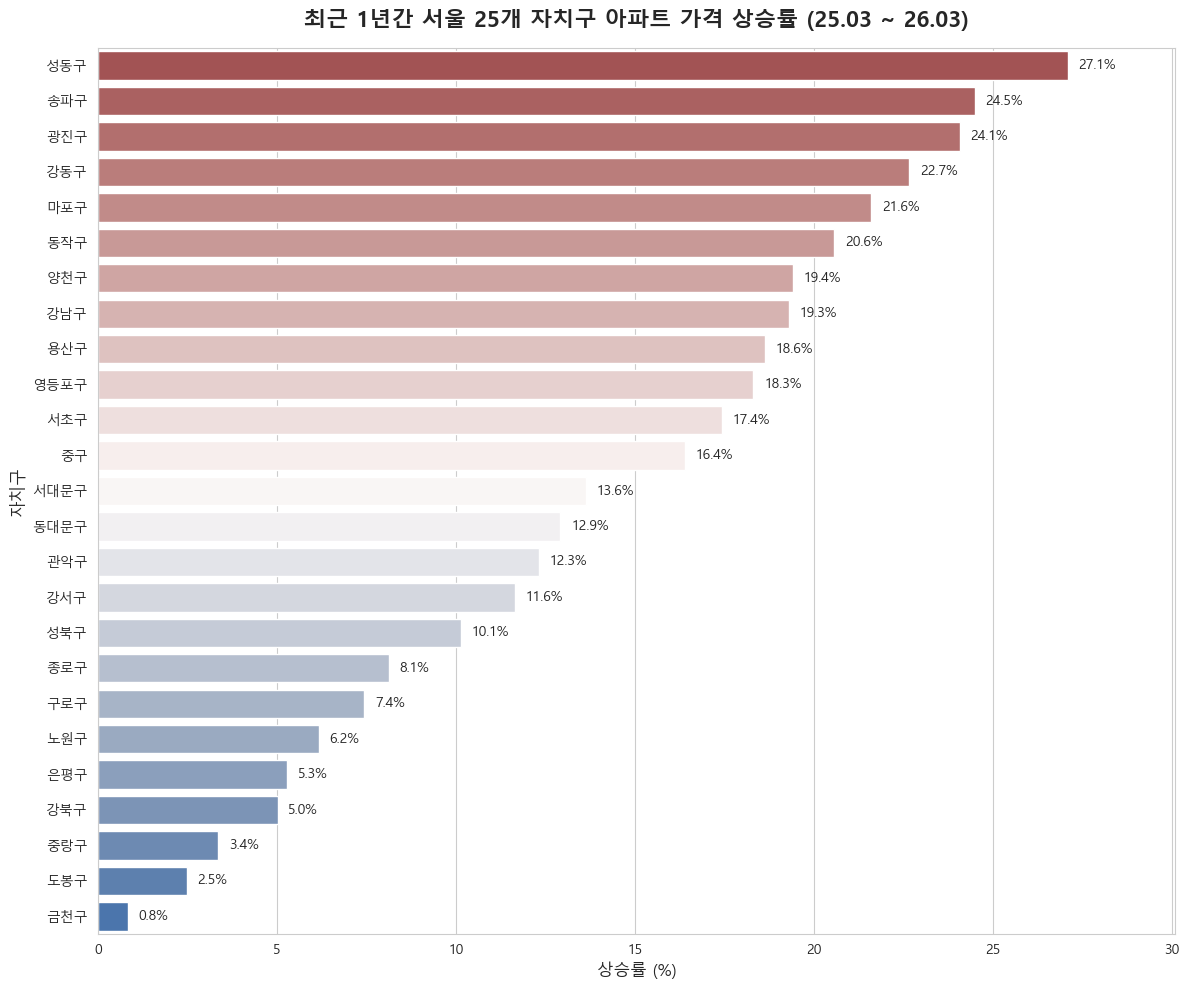

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 25개 구 전체 증감률 데이터를 데이터프레임으로 변환 후 정렬
df_growth = gu_growth.reset_index()
df_growth.columns = ['지역명', '상승률']
df_growth = df_growth.sort_values(by='상승률', ascending=False) # 내림차순 정렬

# 2. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 10)) # 가로 12, 세로 10 (구 개수가 많아서 세로를 길게)
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'



# 3. 가로 막대 그래프 그리기
# (수정됨) hue='지역명'과 legend=False 를 추가합니다.
barplot = sns.barplot(
    data=df_growth, 
    x='상승률', 
    y='지역명', 
    hue='지역명',      # 추가: 색상을 나눌 기준
    palette='vlag_r',  # Red to Blue 그라데이션
    legend=False       # 추가: 불필요한 범례 숨기기
)

# 4. 막대 끝에 실제 수치(%) 적어주기
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.3, p.get_y() + p.get_height()/2, 
             f"{width:.1f}%", 
             ha='left', va='center', fontsize=10)

# 5. 제목 및 축 설정
plt.title(f'최근 1년간 서울 25개 자치구 아파트 가격 상승률 ({one_year_ago.strftime("%y.%m")} ~ {latest_date.strftime("%y.%m")})', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('상승률 (%)', fontsize=12)
plt.ylabel('자치구', fontsize=12)

# 6. x축 범위 여유 있게 설정 (숫자가 잘리지 않도록)
plt.xlim(0, df_growth['상승률'].max() + 3)

plt.tight_layout()
plt.show()

지도 시각화는 엑셀 표나 막대그래프에서는 느끼기 힘든 '공간적인 흐름(입지)'을 직관적으로 파악할 수 있는 최고의 방법입니다.

파이썬에서 지도를 그릴 때 가장 사랑받는 라이브러리인 **folium**을 사용하여, 앞서 구한 25개 구의 상승률 데이터를 서울 지도 위에 색깔로 입혀보겠습니다.

지도를 그리기 위해서는 각 구의 '경계선 좌표'가 담긴 지리 데이터(GeoJSON)가 필요한데, 번거롭게 다운로드할 필요 없이 온라인에서 바로 불러오도록 코드를 구성했습니다.

새로운 셀을 만들고 아래 코드를 실행해 보세요! (만약 folium이 설치되어 있지 않다면 셀 맨 윗줄에 uv add folium을 적고 먼저 실행해 주세요.)

In [20]:
import folium
import requests
import json

# 1. 서울시 25개 자치구 경계선 데이터(GeoJSON) 온라인에서 불러오기
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
geo_json = requests.get(geo_url).json()

# 2. 서울 한복판(남산 근처) 좌표를 중심으로 기본 지도 생성
# tiles='CartoDB positron'은 데이터가 돋보이도록 배경을 옅은 회색조로 만들어 줍니다.
m = folium.Map(location=[37.5502, 126.982], zoom_start=11, tiles='CartoDB positron')

# 3. 단계구분도(Choropleth) 레이어 추가
folium.Choropleth(
    geo_data=geo_json,
    data=df_growth,                    # 앞서 만든 25개구 상승률 데이터프레임
    columns=['지역명', '상승률'],        # [지도와 매칭할 컬럼, 색상으로 표현할 수치 컬럼]
    key_on='feature.properties.name',  # GeoJSON 파일 안에서 구 이름이 들어있는 위치
    fill_color='RdBu_r',               # 색상 테마: 붉은색(Red)과 푸른색(Blue) 사용 (역순_r)
    fill_opacity=0.8,                  # 색상 투명도
    line_opacity=0.3,                  # 경계선 투명도
    legend_name='최근 1년 아파트 매매가격 상승률 (%)'
).add_to(m)

# 4. 노트북 화면에 지도 출력
m

지도가 정말 멋지게 렌더링되었습니다! 붉은색과 푸른색의 대비가 확연해서 서울 부동산의 흐름이 한눈에 들어오네요.

여기에 마우스를 올렸을 때 정확한 수치를 보여주는 툴팁(Tooltip)을 추가하면 시각화의 완성도가 훨씬 높아집니다.

Folium에서 툴팁을 추가할 때 한 가지 알아두어야 할 점은, 엑셀에서 가져온 데이터(df_growth)를 지도 그리는 데이터(geo_json) 안에 직접 '주입'해 주어야 툴팁이 그 숫자를 읽어올 수 있다는 것입니다.

기존 코드에 데이터를 주입하는 과정과 툴팁을 생성하는 코드를 추가하여 완벽하게 작동하도록 구성했습니다. 새로운 셀에 아래 코드를 복사해서 실행해 보세요!

In [22]:
import folium
import requests
import json

# 1. 서울시 자치구 GeoJSON 불러오기
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
geo_json = requests.get(geo_url).json()

# 2. [핵심] GeoJSON 데이터 안에 '상승률' 수치 직접 끼워넣기
# df_growth 데이터를 찾기 쉽게 딕셔너리 형태로 변환합니다. (예: {'성동구': 27.09, ...})
growth_dict = df_growth.set_index('지역명')['상승률'].to_dict()

for feature in geo_json['features']:
    gu_name = feature['properties']['name']
    # 해당 구의 상승률을 찾아서 소수점 둘째 자리까지 추가
    rate = growth_dict.get(gu_name, 0)
    feature['properties']['상승률'] = f"{rate:.2f}%"

# 3. 기본 지도 생성
m = folium.Map(location=[37.5502, 126.982], zoom_start=11, tiles='CartoDB positron')

# 4. 단계구분도(Choropleth) 레이어 생성 (변수 choropleth에 저장)
choropleth = folium.Choropleth(
    geo_data=geo_json,
    data=df_growth,
    columns=['지역명', '상승률'],
    key_on='feature.properties.name',
    fill_color='RdBu_r',
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name='최근 1년 아파트 매매가격 상승률 (%)'
).add_to(m)

# 5. Tooltip (마우스 호버 정보) 추가하기
# Choropleth 내부의 geojson 객체에 툴팁 기능을 추가합니다.
choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['name', '상승률'],           # GeoJSON properties 안에서 읽어올 키 값들
        aliases=['자치구: ', '상승률: '],      # 화면에 보여질 라벨
        style=('background-color: white; color: #333333; font-weight: bold; '
               'font-size: 14px; padding: 10px; border-radius: 5px; box-shadow: 3px 3px 5px rgba(0,0,0,0.2);')
    )
)

# 6. 지도 출력 (쥬피터 노트북 화면에서 보기)
display(m)

# 🌟 7. HTML 파일로 저장하기 (이 부분을 맨 아래에 추가하세요!)
m.save("seoul_apt_map.html")
print("✅ HTML 지도가 성공적으로 저장되었습니다!")

✅ HTML 지도가 성공적으로 저장되었습니다!


가장 뜨거운 상승세를 보인 **TOP 5 자치구(성동구, 송파구, 광진구, 강동구, 마포구)**의 향후 추세(상승 지속 vs 횡보)를 파악하기 위해서는 선 그래프로 흐름을 보는 것이 최고의 방법입니다!

10년 치 전체 데이터를 보면 최근의 미세한 꺾임이나 횡보가 잘 안 보일 수 있으므로, **2020년 이후부터 최근까지의 흐름을 확대(Zoom-in)**해서 보여주고, 각 월별 데이터에 점(마커)을 찍어 꺾이는 방향을 더 명확하게 볼 수 있도록 코드를 작성했습니다.

새로운 셀을 만들고 아래 코드를 실행해 보세요!

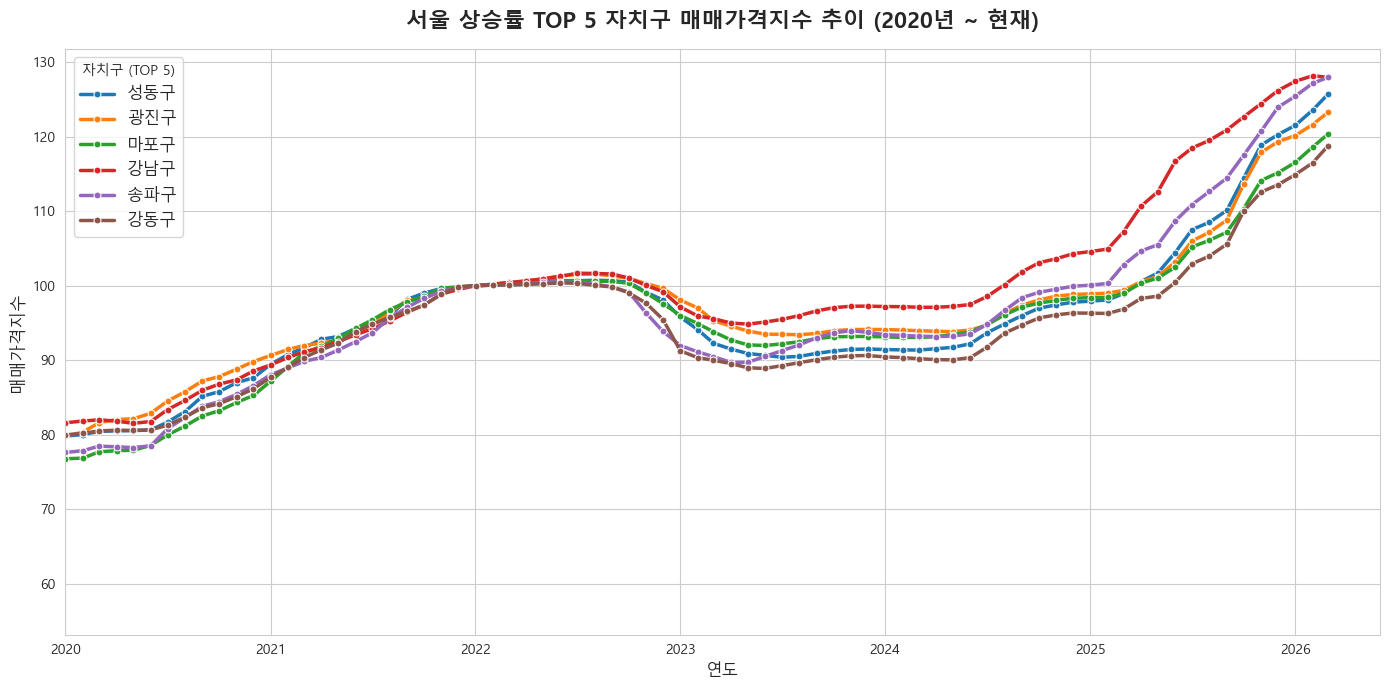

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. TOP 5 자치구 리스트
top5_regions = ['성동구', '송파구', '광진구', '강동구', '마포구','강남구']

# 2. 원본 데이터(df)에서 TOP 5 지역 필터링 및 중복 제거(서울만 남기기)
df_top5 = df[df['지역명'].isin(top5_regions)]
df_top5 = df_top5.drop_duplicates(subset=['지역명'], keep='first')

# 3. 가로 데이터를 세로로 변환 (Melt)
df_top5_long = pd.melt(
    df_top5, 
    id_vars=['지역명'], 
    var_name='날짜', 
    value_name='매매가격지수'
)
df_top5_long['날짜'] = pd.to_datetime(df_top5_long['날짜'], errors='coerce')

# 4. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'

# 5. 선 그래프 그리기 (marker='o'를 추가해서 매월의 꺾임을 명확히 표시)
sns.lineplot(
    data=df_top5_long, 
    x='날짜', 
    y='매매가격지수', 
    hue='지역명', 
    linewidth=2.5,
    marker='o',    # 데이터 포인트에 점 찍기
    markersize=5   # 점 크기
)

# 6. 최근 추세를 자세히 보기 위해 x축(날짜) 범위를 2020년 이후로 제한 (줌인 효과)
# (만약 전체 기간을 보고 싶다면 아래 코드를 주석(#) 처리하세요)
plt.xlim(pd.to_datetime('2020-01-01'), df_top5_long['날짜'].max() + pd.DateOffset(months=3))

# 7. 제목 및 축 설정
plt.title('서울 상승률 TOP 5 자치구 매매가격지수 추이 (2020년 ~ 현재)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('매매가격지수', fontsize=12)

# 범례 위치를 그래프 밖이나 빈 공간으로 배치
plt.legend(title='자치구 (TOP 5)', fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

좋습니다! 이제 시야를 넓혀서 **대한민국 주요 거점 도시들(광역지자체)** 의 데이터를 비교해 볼 차례군요. 서울이 불타오를 때 지방 대도시들은 어떤 흐름을 보였는지 확인하면 대한민국 부동산 지도의 큰 그림을 완벽히 이해하실 수 있습니다.

이번에도 **중복 데이터 문제(전국에 흩어진 같은 이름의 구)** 를 방지하고, 깔끔하게 '시/도' 단위의 핵심 지역만 골라내어 시각화하는 코드를 짜드리겠습니다.

📊 전국 주요 도시 매매가격지수 비교 분석  
새 셀에 아래 코드를 복사해서 실행해 보세요!

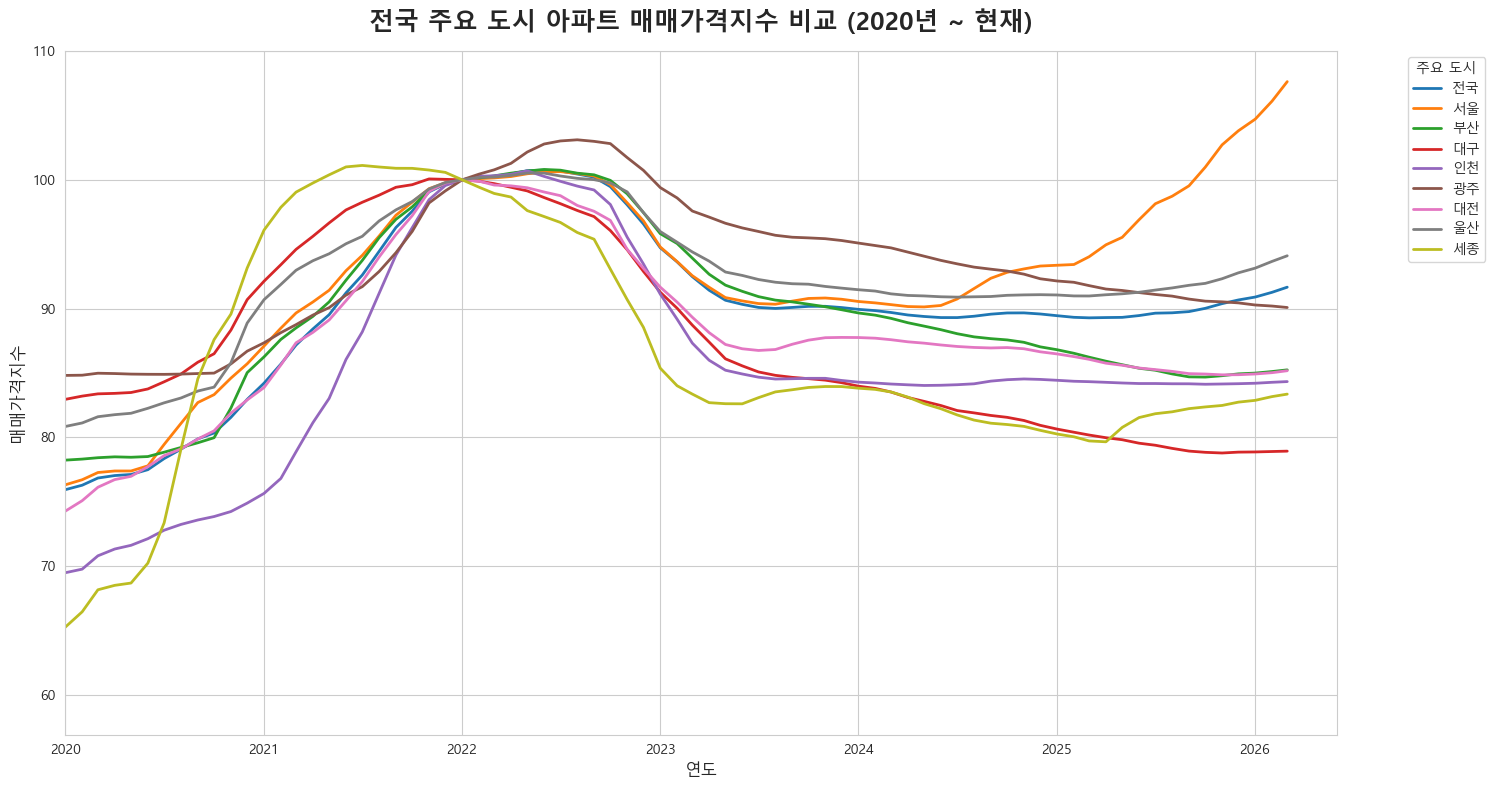

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 비교할 주요 광역 도시 리스트
major_cities = ['전국', '서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종']

# 2. 원본 데이터(df)에서 해당 지역만 필터링
# (시/도 단위 데이터는 보통 리스트 앞쪽에 나오므로 중복 제거 시 첫 번째 값을 유지합니다)
df_cities = df[df['지역명'].isin(major_cities)]
df_cities = df_cities.drop_duplicates(subset=['지역명'], keep='first')

# 3. 데이터 구조 변환 (Melt)
df_cities_long = pd.melt(
    df_cities, 
    id_vars=['지역명'], 
    var_name='날짜', 
    value_name='매매가격지수'
)
df_cities_long['날짜'] = pd.to_datetime(df_cities_long['날짜'], errors='coerce')

# 4. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'

# 5. 선 그래프 그리기
# 지역이 많으므로 선 굵기를 조금 조절하고, 전국 평균(파란선 등)을 잘 보이게 합니다.
sns.lineplot(
    data=df_cities_long, 
    x='날짜', 
    y='매매가격지수', 
    hue='지역명', 
    linewidth=2
)

# 6. 최근 추세 확인을 위해 2020년 이후로 줌인 (원하시면 주석처리 하세요)
plt.xlim(pd.to_datetime('2020-01-01'), df_cities_long['날짜'].max() + pd.DateOffset(months=3))

# 7. 제목 및 축 설정
plt.title('전국 주요 도시 아파트 매매가격지수 비교 (2020년 ~ 현재)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('매매가격지수', fontsize=12)
plt.legend(title='주요 도시', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 밖으로

plt.tight_layout()
plt.show()

🚀 분석의 완성을 위한 제안: "전국 자치구 상승률 TOP 10"
서울 안에서 성동구가 1위였던 것처럼, 이제 시야를 전국으로 넓혀서 최근 1년간 대한민국에서 가장 뜨거웠던 자치구 10곳을 뽑아보면 어떨까요? 서울의 강남권이 1등일지, 아니면 의외의 지방 도시가 끼어있을지 확인하는 재미가 있을 겁니다.

아래 코드로 전국구 성적표를 확인해 보세요!

In [27]:
# 1. 시/도 단위를 제외한 순수 '구/군' 단위 데이터만 필터링
# 지역명에 '구' 또는 '군'이 포함된 데이터 추출 (중복 제거 포함)
df_all_gu = df[df['지역명'].str.endswith(('구', '군'), na=False)].copy()
df_all_gu = df_all_gu.drop_duplicates(subset=['지역명'], keep='first')

# 2. 실제 데이터프레임의 컬럼에서 날짜 컬럼들만 리스트로 추출
# (보통 첫 번째 컬럼인 '지역명'을 제외한 나머지가 날짜입니다)
date_columns = [col for col in df.columns if col != '지역명']

# 3. 마지막 날짜(가장 최근)와 그로부터 12개월 전 날짜 컬럼 찾기
latest_col = date_columns[-1]
past_col = date_columns[-13] # 뒤에서 13번째가 딱 1년 전 (12개월 차이)

print(f"✅ 분석 기준: {past_col} 대비 {latest_col} 상승률")

# 4. 상승률 계산 (숫자형 변환 포함)
latest_p = pd.to_numeric(df_all_gu[latest_col], errors='coerce')
past_p = pd.to_numeric(df_all_gu[past_col], errors='coerce')

growth_all = ((latest_p - past_p) / past_p) * 100
df_all_gu['상승률'] = growth_all

# 5. 결과 출력 (상위 10개)
top10_nationwide = df_all_gu.sort_values(by='상승률', ascending=False).head(10)

print(f"\n🏆 최근 1년간 전국 아파트 가격 상승률 TOP 10")
print("-" * 50)
for rank, (_, row) in enumerate(top10_nationwide.iterrows(), 1):
    print(f"{rank}위: {row['지역명']} (+{row['상승률']:.2f}%)")

✅ 분석 기준: 2025-03-01 09:00:52 대비 2026-03-01 09:00:52 상승률

🏆 최근 1년간 전국 아파트 가격 상승률 TOP 10
--------------------------------------------------
1위: 성동구 (+27.09%)
2위: 성남시 분당구 (+27.08%)
3위: 송파구 (+24.49%)
4위: 광진구 (+24.07%)
5위: 강동구 (+22.67%)
6위: 마포구 (+21.61%)
7위: 동작구 (+20.57%)
8위: 양천구 (+19.42%)
9위: 강남구 (+19.30%)
10위: 용산구 (+18.63%)


🚀 시각화의 마지막 퍼즐: "전국 TOP 10 지역 한눈에 비교하기"
이 10개 지역의 상승률을 막대그래프로 시각화하면 보고서용으로 아주 훌륭한 자료가 됩니다. 특히 서울과 비서울(분당)을 색깔로 구분해서 그려주면 더 인상적인 그래프가 됩니다.

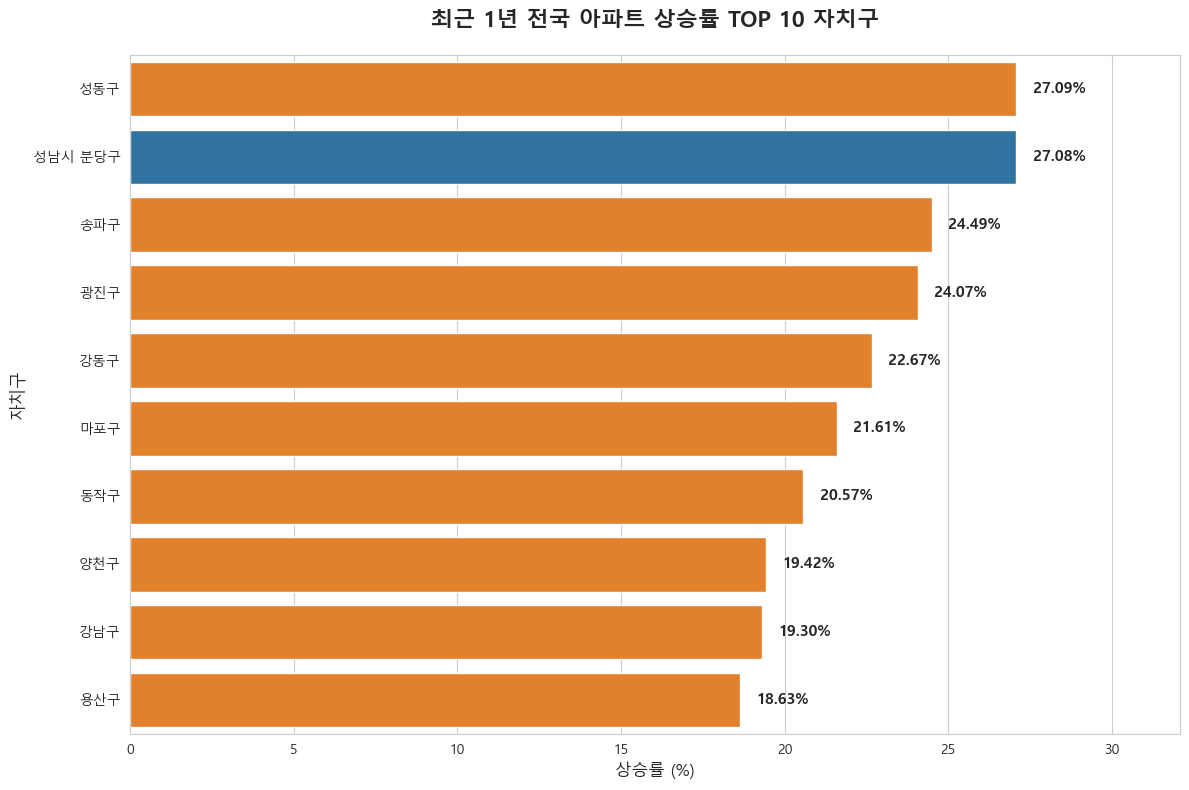

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns  # 🌟 이 부분을 수정했습니다!

# 1. 시각화용 데이터 준비
top10_df = top10_nationwide.copy()
# '서울' 포함 여부에 따라 그룹 나누기
top10_df['is_seoul'] = top10_df['지역명'].apply(lambda x: '서울' if any(gu in x for gu in seoul_gu_list) else '경기/지방')

# 2. 그래프 그리기
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 서울 지역은 주황색, 그 외 지역(분당 등)은 파란색으로 구분
colors = ['#ff7f0e' if x == '서울' else '#1f77b4' for x in top10_df['is_seoul']]

# 막대 그래프 생성
barplot = sns.barplot(
    data=top10_df, 
    x='상승률', 
    y='지역명', 
    palette=colors,
    hue='지역명',
    legend=False
)

# 수치 표시 (%)
for i, rate in enumerate(top10_df['상승률']):
    plt.text(rate + 0.5, i, f'{rate:.2f}%', va='center', fontsize=11, fontweight='bold')

plt.title('최근 1년 전국 아파트 상승률 TOP 10 자치구', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('상승률 (%)', fontsize=12)
plt.ylabel('자치구', fontsize=12)
plt.xlim(0, top10_df['상승률'].max() + 5)

plt.tight_layout()
plt.show()

🚀 데이터 분석의 마지막 '화룡점정': 경기도 분석
서울과 전국의 큰 흐름을 보셨으니, 마지막으로 경기도 내에서 가장 핫한 지역 TOP 10을 뽑아보는 건 어떨까요? 분당 외에 어떤 경기도 도시들이 상승세를 타고 있는지 확인하면 수도권 투자의 전체 지도가 완성됩니다.

아래 코드로 경기도의 순위를 확인해 보세요. (이미 df와 major_cities 등의 변수가 있으니 바로 실행하시면 됩니다.)

In [30]:
# 1. 경기도 자치구/시/군 리스트 필터링
# (엑셀 원본의 지역명 체계에 따라 경기도 지역만 골라냅니다)
# 보통 '수원시 영통구'처럼 되어 있거나 '과천시'처럼 되어 있습니다.
gyeonggi_keywords = ['수원', '성남', '의정부', '안양', '부천', '광명', '평택', '동두천', '안산', '고양', 
                    '과천', '구리', '남양주', '오산', '시흥', '군포', '의왕', '하남', '용인', '파주', 
                    '이천', '안성', '김포', '화성', '광주', '양주', '포천', '여주', '연천', '가평', '양평']

df_gyeonggi = df[df['지역명'].str.contains('|'.join(gyeonggi_keywords), na=False)].copy()
df_gyeonggi = df_gyeonggi.drop_duplicates(subset=['지역명'], keep='first')

# 2. 1년 전 대비 상승률 계산
latest_col = date_columns[-1]
past_col = date_columns[-13]

latest_p_gg = pd.to_numeric(df_gyeonggi[latest_col], errors='coerce')
past_p_gg = pd.to_numeric(df_gyeonggi[past_col], errors='coerce')

df_gyeonggi['상승률'] = ((latest_p_gg - past_p_gg) / past_p_gg) * 100

# 3. 경기도 TOP 10 추출 및 출력
top10_gyeonggi = df_gyeonggi.sort_values(by='상승률', ascending=False).head(10)

print(f"🏆 최근 1년간 경기도 아파트 상승률 TOP 10")
print("-" * 50)
for rank, (_, row) in enumerate(top10_gyeonggi.iterrows(), 1):
    print(f"{rank}위: {row['지역명']} (+{row['상승률']:.2f}%)")

🏆 최근 1년간 경기도 아파트 상승률 TOP 10
--------------------------------------------------
1위: 성남시 분당구 (+27.08%)
2위: 성남시 (+22.37%)
3위: 과천시 (+19.03%)
4위: 용인시 수지구 (+15.82%)
5위: 안양시 동안구 (+15.44%)
6위: 하남시 (+15.09%)
7위: 성남시 수정구 (+14.44%)
8위: 광명시 (+14.42%)
9위: 성남시 중원구 (+12.35%)
10위: 안양시 (+11.56%)


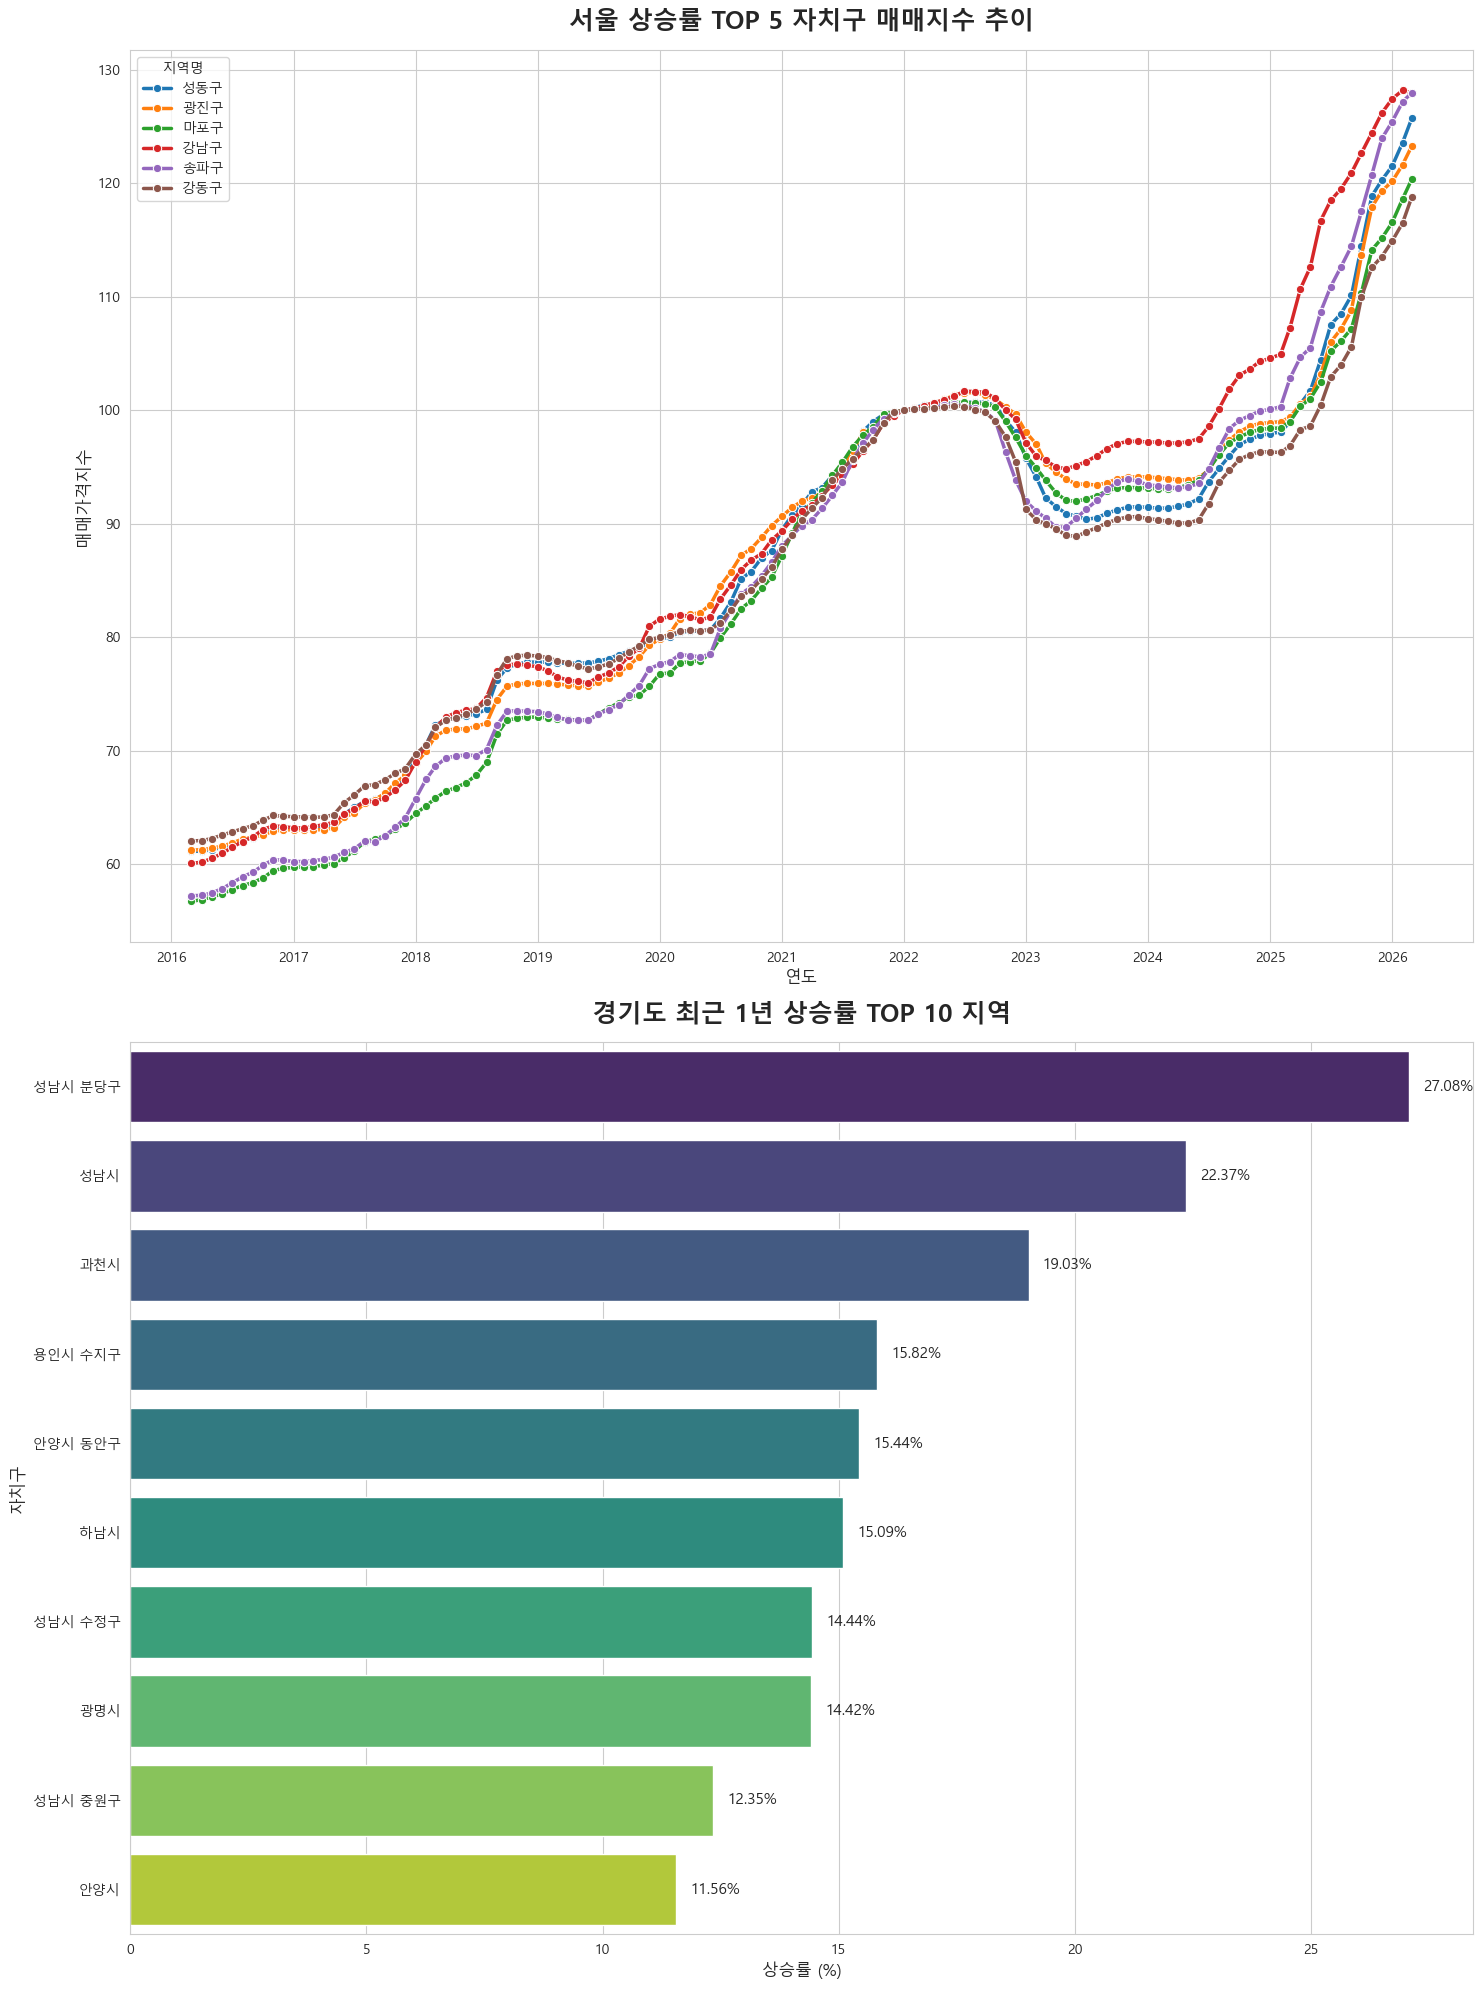

✅ 경고 없이 'real_estate_total_report.png' 파일이 성공적으로 저장되었습니다!


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2행 1열짜리 큰 도화지 만들기 (크기를 충분히 크게 잡습니다)
fig, axes = plt.subplots(2, 1, figsize=(15, 20))

# --- [첫 번째 그래프] 서울 TOP 5 추이 (선 그래프) ---
sns.lineplot(
    data=df_top5_long, 
    x='날짜', 
    y='매매가격지수', 
    hue='지역명', 
    ax=axes[0], 
    linewidth=2.5, 
    marker='o'
)
axes[0].set_title('서울 상승률 TOP 5 자치구 매매지수 추이', fontsize=18, fontweight='bold', pad=15)
axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('매매가격지수', fontsize=12)

# --- [두 번째 그래프] 경기도 TOP 10 상승률 (막대 그래프) ---
# 🌟 경고 해결 포인트: hue='지역명'과 legend=False를 추가했습니다.
sns.barplot(
    data=top10_gyeonggi, 
    x='상승률', 
    y='지역명', 
    ax=axes[1], 
    hue='지역명',      # 추가: 색상 기준 명시
    palette='viridis', 
    legend=False       # 추가: 중복 범례 제거
)
axes[1].set_title('경기도 최근 1년 상승률 TOP 10 지역', fontsize=18, fontweight='bold', pad=15)
axes[1].set_xlabel('상승률 (%)', fontsize=12)
axes[1].set_ylabel('자치구', fontsize=12)

# 막대 끝에 수치 표시하는 루프 (가독성 향상)
for p in axes[1].patches:
    width = p.get_width()
    axes[1].text(width + 0.3, p.get_y() + p.get_height()/2, f"{width:.2f}%", ha='left', va='center', fontsize=11)

# 2. 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig('real_estate_total_report.png', dpi=300)
plt.show()

print("✅ 경고 없이 'real_estate_total_report.png' 파일이 성공적으로 저장되었습니다!")

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# 1. PDF 파일 경로 설정
pdf_filename = '부동산_시장_분석_최종_리포트.pdf'

# 2. PDF 생성 시작
with PdfPages(pdf_filename) as pdf:
    
    # --- PAGE 1: 서울 상승률 TOP 5 추이 (선 그래프) ---
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=df_top5_long, x='날짜', y='매매가격지수', hue='지역명', linewidth=2.5, marker='o')
    plt.title('서울 상승률 TOP 5 자치구 매매지수 추이', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('연도', fontsize=12)
    plt.ylabel('매매가격지수', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    pdf.savefig()  # 현재 그래프를 PDF 첫 페이지로 저장
    plt.close()    # 메모리 확보를 위해 현재 figure 닫기

    # --- PAGE 2: 서울 25개 자치구 상승률 순위 (막대 그래프) ---
    plt.figure(figsize=(12, 12))
    # df_growth 데이터 사용 (아까 만든 25개구 전체 상승률 데이터프레임)
    barplot_seoul = sns.barplot(data=df_growth, x='상승률', y='지역명', hue='지역명', palette='vlag_r', legend=False)
    plt.title('최근 1년 서울 25개 자치구 아파트 상승률 성적표', fontsize=18, fontweight='bold', pad=20)
    
    # 막대 끝 수치 표시
    for p in barplot_seoul.patches:
        width = p.get_width()
        plt.text(width + 0.3, p.get_y() + p.get_height()/2, f"{width:.1f}%", ha='left', va='center')
    
    pdf.savefig()
    plt.close()

    # --- PAGE 3: 전국 주요 도시 비교 (선 그래프) ---
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=df_cities_long, x='날짜', y='매매가격지수', hue='지역명', linewidth=2)
    plt.title('전국 주요 도시 매매가격지수 비교 (2020~현재)', fontsize=18, fontweight='bold', pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    pdf.savefig(bbox_inches='tight') # 범례가 밖으로 나가 있으므로 잘리지 않게 설정
    plt.close()

    # --- PAGE 4: 경기도 상승률 TOP 10 (막대 그래프) ---
    plt.figure(figsize=(12, 8))
    barplot_gg = sns.barplot(data=top10_gyeonggi, x='상승률', y='지역명', hue='지역명', palette='viridis', legend=False)
    plt.title('경기도 최근 1년 상승률 TOP 10 지역', fontsize=18, fontweight='bold', pad=20)
    
    for p in barplot_gg.patches:
        width = p.get_width()
        plt.text(width + 0.3, p.get_y() + p.get_height()/2, f"{width:.2f}%", ha='left', va='center')
    
    pdf.savefig()
    plt.close()

print(f"🎉 모든 분석 결과가 '{pdf_filename}' 파일로 저장되었습니다!")

🎉 모든 분석 결과가 '부동산_시장_분석_최종_리포트.pdf' 파일로 저장되었습니다!
